In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#ml
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import precision_recall_curve, f1_score, accuracy_score
from sklearn.metrics import  precision_score, recall_score

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, PrecisionRecallDisplay, roc_curve
from sklearn.model_selection import GridSearchCV


In [5]:
df = pd.read_csv('creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [6]:
df.isnull().sum().sum()

0

In [7]:
df.duplicated().sum()

1081

In [8]:
df.drop_duplicates(keep='first', inplace=True)

In [9]:
df.shape

(283726, 31)

# EDA (exploratory data analysis)

In [10]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [11]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


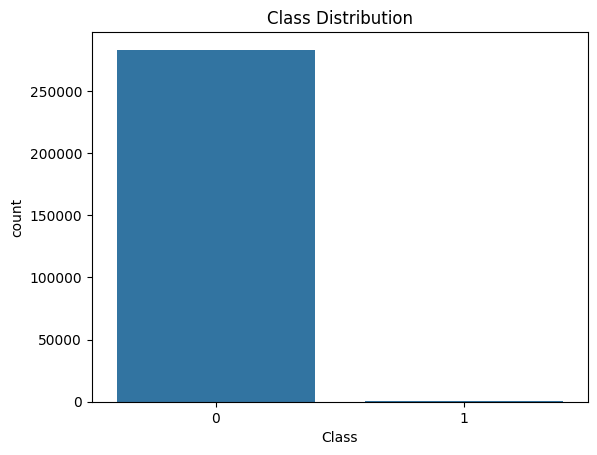

In [12]:
plt.title("Class Distribution")
sns.countplot(x='Class', data=df);

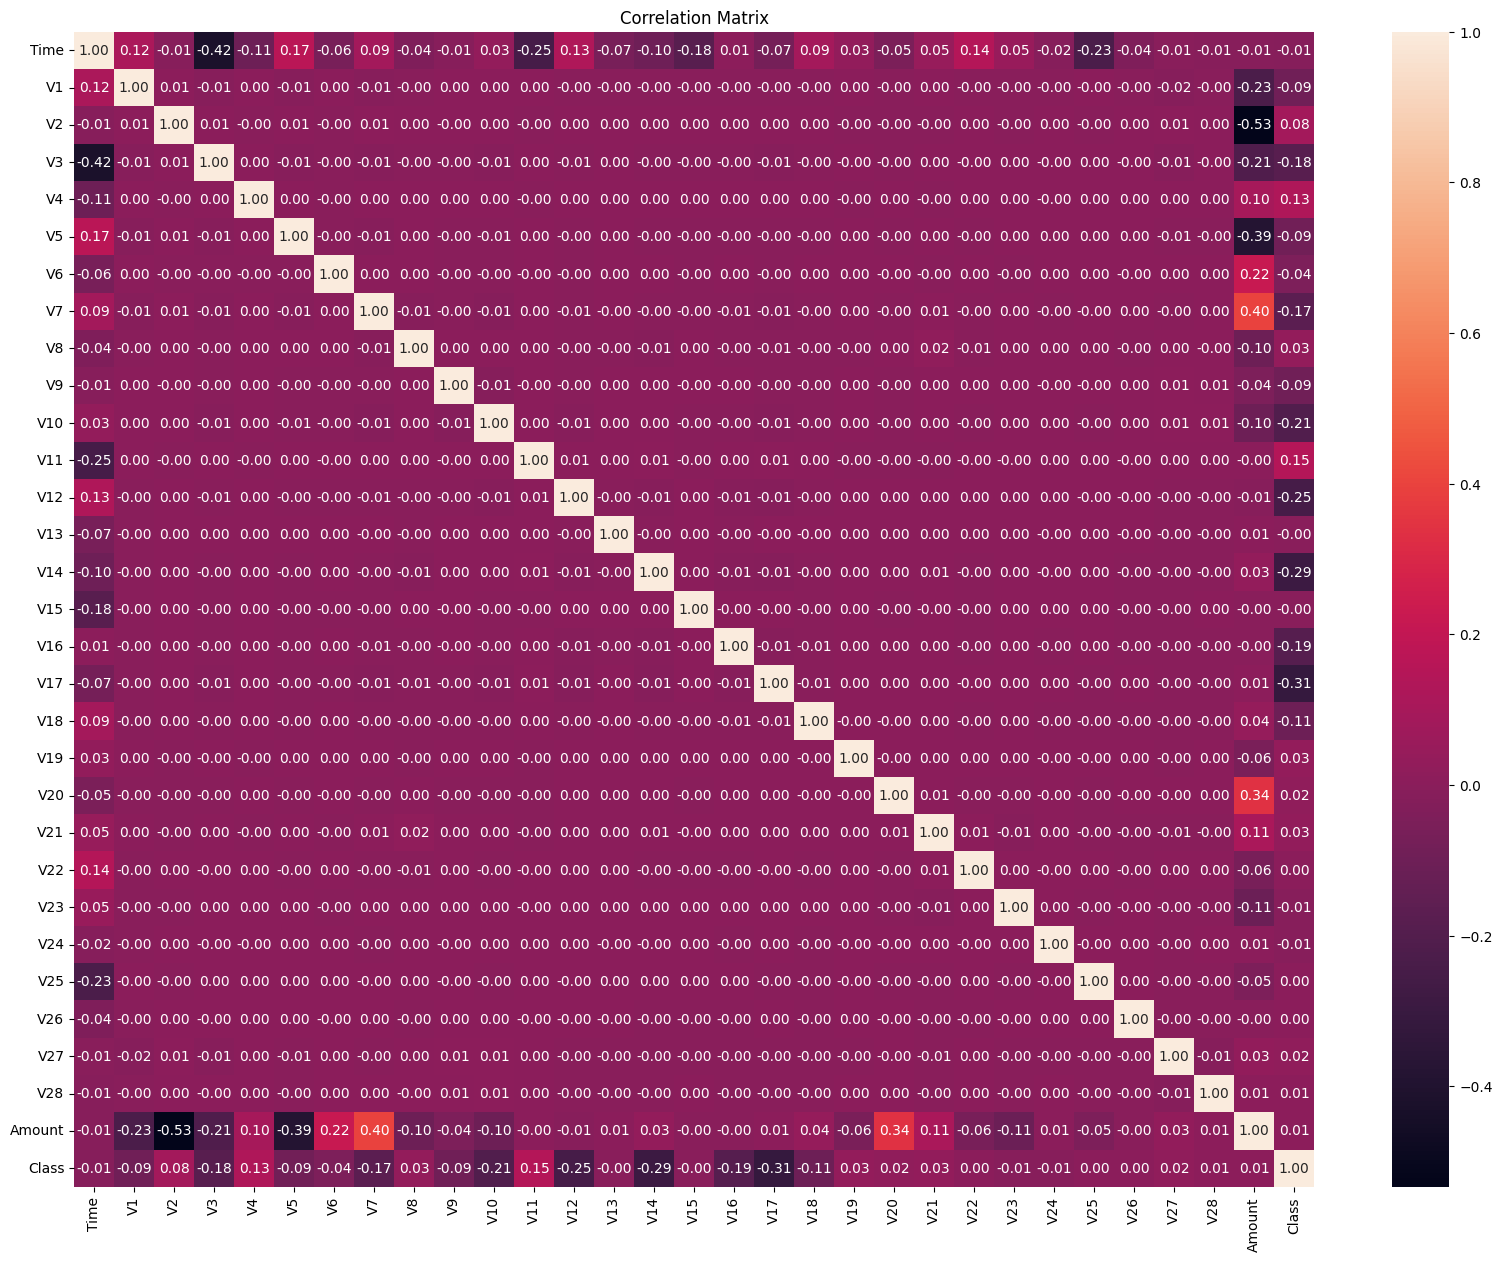

In [13]:
plt.figure(figsize = (20,15))
sns.heatmap(df.corr(),annot=True, fmt= '.2f')
plt.title('Correlation Matrix')
plt.show()

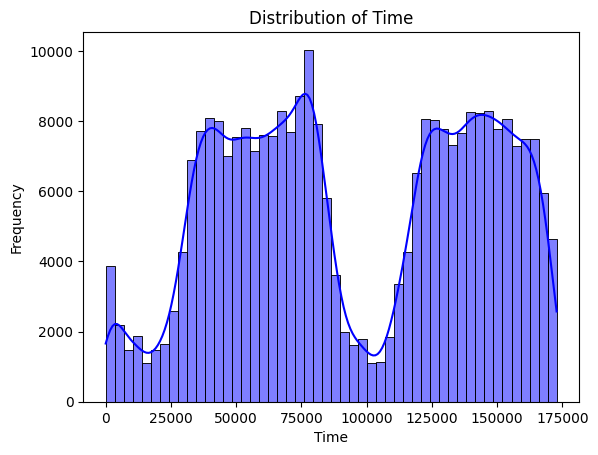

In [14]:
# plt.figure(figsize = ())
sns.histplot(df['Time'], bins = 50, kde = True, color = 'blue')
plt.title('Distribution of Time')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

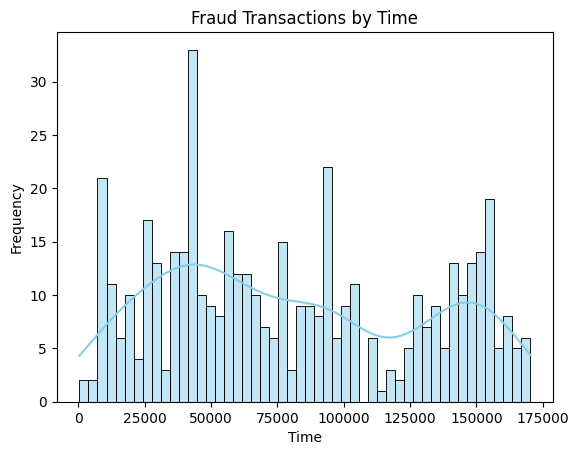

In [15]:
fraud = df[df['Class'] == 1]['Time']
plt.title('Fraud Transactions by Time')
plt.ylabel('Frequency')
sns.histplot(fraud, color='skyblue', kde=True, bins=50);

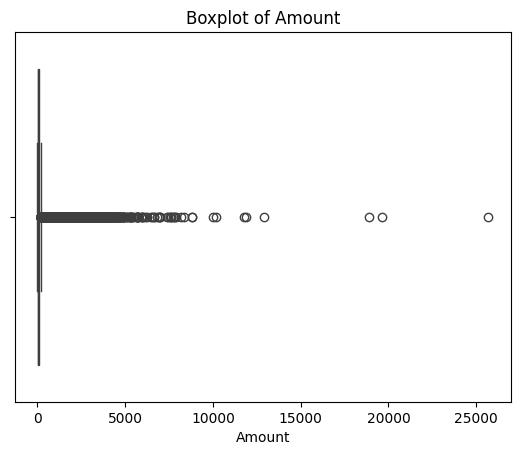

In [16]:
plt.title('Boxplot of Amount')
sns.boxplot(data=df, x='Amount');

In [17]:
x = df.drop('Class', axis=1)
y = df['Class']

# train test split

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.20, random_state=42)

In [19]:
x_train.shape, y_train.shape

((226980, 30), (226980,))

In [20]:
x_test.shape, y_test.shape

((56746, 30), (56746,))

In [21]:
def evaluation_model(y_actual, y_pred):
    roc = roc_auc_score(y_actual, y_pred)
    precision = precision_score(y_actual, y_pred)
    recall = recall_score(y_actual, y_pred)
    f1 = f1_score(y_actual, y_pred)
    accuracy = accuracy_score(y_actual, y_pred)

    return {
        "ROC_AUC": roc,
        "Precision": precision,
        'accuracy' : accuracy,
        "Recall": recall,
        "F1": f1,
    }

In [22]:
negative_class = np.sum(y_test == 0)
positive_class = np.sum(y_test == 1)
ratio = negative_class / positive_class
ratio

596.3263157894737

In [23]:
xg = XGBClassifier(scale_pos_weight=596)

In [24]:
xg.fit(x_train, y_train)
pred_train = xg.predict(x_train)
pred_test = xg.predict(x_test)

In [25]:
#Training
evaluation_model(y_train, pred_train)

{'ROC_AUC': 1.0, 'Precision': 1.0, 'accuracy': 1.0, 'Recall': 1.0, 'F1': 1.0}

In [26]:
#Testing
evaluation_model(y_test, pred_test)

{'ROC_AUC': 0.889447206301928,
 'Precision': 0.961038961038961,
 'accuracy': 0.9995770627004547,
 'Recall': 0.7789473684210526,
 'F1': 0.8604651162790697}

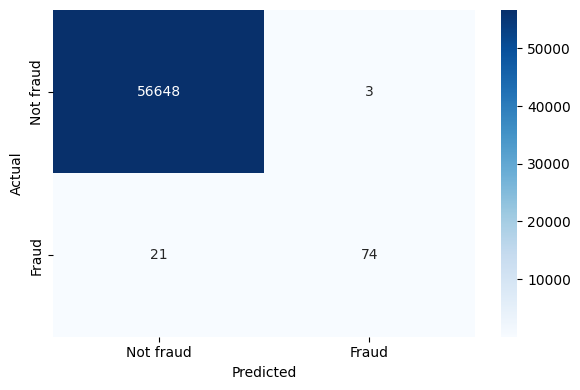

In [27]:

fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test,pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not fraud', 'Fraud'],
            yticklabels=['Not fraud', 'Fraud'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

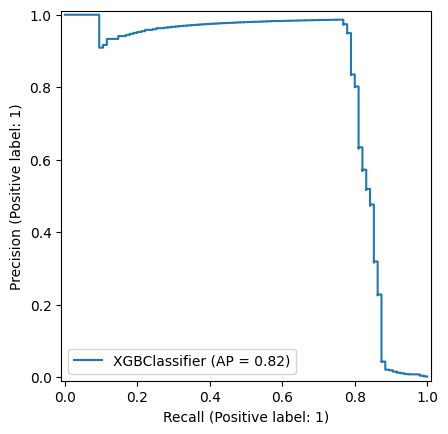

In [28]:
PrecisionRecallDisplay.from_estimator(xg, x_test, y_test);

In [29]:
pred_test_proba = xg.predict_proba(x_test)
pred_test_proba = pred_test_proba[:, 1]

# --- Impact of Different Thresholds on Fraud Detection Performance ---
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

print(f"{'Threshold':>10} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10} | {'Fraud Caught':>13} | {'False Alarms':>13}")
print("-" * 85)

for t in thresholds_to_test:
    preds_t = (pred_test_proba >= t).astype(int)
    report = classification_report(y_test, preds_t, output_dict=True, zero_division=0)
    fraud_caught = preds_t[y_test == 1].sum()
    false_alarms = preds_t[y_test == 0].sum()
    total_fraud = y_test.sum()
    print(f"{t:>10.1f} | {report['1']['precision']:>10.4f} | {report['1']['recall']:>10.4f} | "
          f"{report['1']['f1-score']:>10.4f} | {fraud_caught:>6d}/{total_fraud:<6d} | {false_alarms:>13,}")

 Threshold |  Precision |     Recall |   F1-Score |  Fraud Caught |  False Alarms
-------------------------------------------------------------------------------------
       0.1 |     0.8000 |     0.8000 |     0.8000 |     76/95     |            19
       0.2 |     0.8929 |     0.7895 |     0.8380 |     75/95     |             9
       0.3 |     0.9375 |     0.7895 |     0.8571 |     75/95     |             5
       0.4 |     0.9494 |     0.7895 |     0.8621 |     75/95     |             4
       0.5 |     0.9610 |     0.7789 |     0.8605 |     74/95     |             3
       0.6 |     0.9610 |     0.7789 |     0.8605 |     74/95     |             3
       0.7 |     0.9610 |     0.7789 |     0.8605 |     74/95     |             3
       0.8 |     0.9733 |     0.7684 |     0.8588 |     73/95     |             2


# hyperparameter training

In [284]:
param = {
    'n_estimators' : [200, 300, 500],
    'max_depth' : [6, 8, 10],
    'gamma' : [0.2, 0.4],
    'learning_rate' : [0.1, 0.01],
    'random_state' : [42, 2],
    'scale_pos_weight' : [596]
}

In [286]:
grid = GridSearchCV(XGBClassifier(), param_grid=param, scoring='accuracy', n_jobs=-1)
grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gamma': [0.2, 0.4], 'learning_rate': [0.1, 0.01], 'max_depth': [6, 8, ...], 'n_estimators': [200, 300, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [287]:
best_param = grid.best_params_
best_param

{'gamma': 0.2,
 'learning_rate': 0.1,
 'max_depth': 6,
 'n_estimators': 200,
 'random_state': 42,
 'scale_pos_weight': 596}

In [288]:
hxg = XGBClassifier(**best_param)
hxg.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[str], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = loa

In [289]:
hyper_train_pred = hxg.predict(x_train)
hyper_test_pred = hxg.predict(x_test)

In [290]:
# Training Result
evaluation_model(y_train, hyper_train_pred)

{'ROC_AUC': 0.9999977934881422,
 'Precision': 0.9973614775725593,
 'accuracy': 0.9999955943254912,
 'Recall': 1.0,
 'F1': 0.9986789960369881}

In [291]:
# Testing Result
evaluation_model(y_test, hyper_test_pred)

{'ROC_AUC': 0.8841575704985929,
 'Precision': 0.9240506329113924,
 'accuracy': 0.9995065731505305,
 'Recall': 0.7684210526315789,
 'F1': 0.8390804597701149}

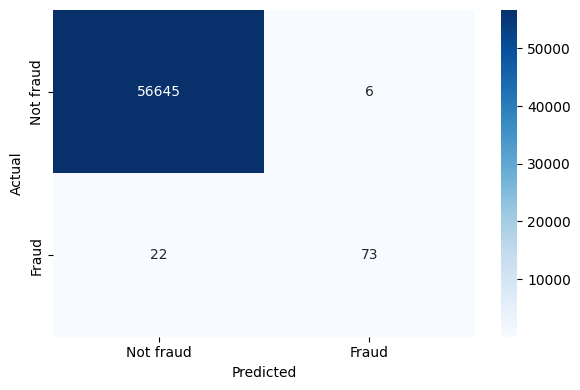

In [297]:

fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test, hyper_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not fraud', 'Fraud'],
            yticklabels=['Not fraud', 'Fraud'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [293]:
hyper_pred_test_proba = hxg.predict_proba(x_test)
hyper_pred_test_proba = hyper_pred_test_proba[:, 1]

# --- Impact of Different Thresholds on Fraud Detection Performance ---
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

print(f"{'Threshold':>10} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10} | {'Fraud Caught':>13} | {'False Alarms':>13}")
print("-" * 85)

for t in thresholds_to_test:
    preds_t = (hyper_pred_test_proba >= t).astype(int)
    report = classification_report(y_test, preds_t, output_dict=True, zero_division=0)
    fraud_caught = preds_t[y_test == 1].sum()
    false_alarms = preds_t[y_test == 0].sum()
    total_fraud = y_test.sum()
    print(f"{t:>10.1f} | {report['1']['precision']:>10.4f} | {report['1']['recall']:>10.4f} | "
          f"{report['1']['f1-score']:>10.4f} | {fraud_caught:>6d}/{total_fraud:<6d} | {false_alarms:>13,}")

 Threshold |  Precision |     Recall |   F1-Score |  Fraud Caught |  False Alarms
-------------------------------------------------------------------------------------
       0.1 |     0.7755 |     0.8000 |     0.7876 |     76/95     |            22
       0.2 |     0.8444 |     0.8000 |     0.8216 |     76/95     |            14
       0.3 |     0.8824 |     0.7895 |     0.8333 |     75/95     |            10
       0.4 |     0.9250 |     0.7789 |     0.8457 |     74/95     |             6
       0.5 |     0.9241 |     0.7684 |     0.8391 |     73/95     |             6
       0.6 |     0.9605 |     0.7684 |     0.8538 |     73/95     |             3
       0.7 |     0.9733 |     0.7684 |     0.8588 |     73/95     |             2
       0.8 |     0.9733 |     0.7684 |     0.8588 |     73/95     |             2


In [294]:
import pickle

In [296]:
pickle.dump(xg, open('credit_card_fraud.pkl', 'wb'))